<a href="https://colab.research.google.com/github/SANGRAMLEMBE/100_days_of_ML/blob/main/Day38_%20Missing%20Indicator/Random_Sample_Imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [17]:
df = pd.read_csv('train.csv', usecols = ['Age','Fare','Survived'])

In [18]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [19]:
df.isnull().mean()*100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [20]:
x = df.drop(columns=['Survived'])
y = df["Survived"]

In [21]:
from IPython.lib.security import random
X_train, X_test,y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [22]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [23]:
X_test.head()

,Age,Fare,Age_imputed
707,42.0,26.2875,42.0
37,21.0,8.0500,21.0
615,24.0,65.0000,24.0
169,28.0,56.4958,28.0
68,17.0,7.9250,17.0


In [24]:
X_train['Age_imputed'][X_train['Age'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipykernel_2460/2139142109.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_2460/2139142109.py:2: Fu

In [25]:
X_train['Age_imputed']

,Age_imputed
30,40.0
10,4.0
873,47.0
182,9.0
876,20.0
...,...
534,30.0
584,50.0
493,71.0
527,4.0


In [26]:
X_train['Age_imputed'][X_train['Age'].isnull()]

,Age_imputed
77,6.0
868,39.0
334,24.0
295,47.0
792,26.0
...,...
674,62.0
466,31.0
584,50.0
527,4.0


In [27]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([35.  , 51.  , 17.  ,  0.83, 23.  , 22.  , 40.  , 22.  , 59.  ,
       27.  , 41.  , 21.  , 32.  , 17.  , 32.  , 19.  , 16.  , 36.5 ,
       38.  , 44.  , 34.  , 18.  , 42.  , 34.  , 37.  , 71.  , 36.  ,
       27.  ,  9.  , 28.  , 28.  , 19.  , 45.  , 39.  , 54.  , 14.5 ,
       33.  , 36.  , 20.  , 60.  , 35.  , 31.  ,  1.  , 18.  , 25.  ,
       45.  ,  9.  , 37.  , 28.  , 33.  , 18.  , 40.  ,  3.  , 21.  ,
       42.  , 36.  , 22.  , 43.  , 27.  , 15.  ,  2.  , 24.  , 18.  ,
       39.  , 42.  , 57.  , 49.  , 46.  , 35.  , 30.  , 30.  , 36.  ,
       23.  , 17.  , 36.  , 16.  , 34.  ,  6.  , 23.5 , 59.  , 34.  ,
       31.  ,  0.42, 42.  , 31.  , 21.  , 28.  , 24.  , 32.  , 26.  ,
       31.  , 21.  , 28.  , 39.  , 22.  , 61.  , 36.  , 43.  , 45.  ,
       49.  ,  7.  , 19.  , 22.  , 20.  , 56.  , 35.  , 16.  , 18.  ,
       49.  , 19.  , 41.  , 36.  , 52.  , 51.  , 44.  , 60.  , 22.  ,
       26.  , 21.  , 28.  , 22.  , 44.  ,  9.  , 20.  , 28.  , 25.  ,
       18.  , 34.  ,

In [28]:
# it will fill random sample values, where we have NAN values

X_train['Age'].dropna().sample(1).values

array([27.])

In [30]:
# this is will define how much random numbers we needed here

X_train['Age'].isnull().sum()

np.int64(148)

In [31]:
# Here we have missing values in Age but they filled in Age_imputed

X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,50.0
493,71.0,49.5042,71.0
527,NaN,221.7792,4.0


/tmp/ipykernel_2460/1555788021.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label = 'Original')
/tmp/ipykernel_2460/1555788021.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'],label = 'Imputed')


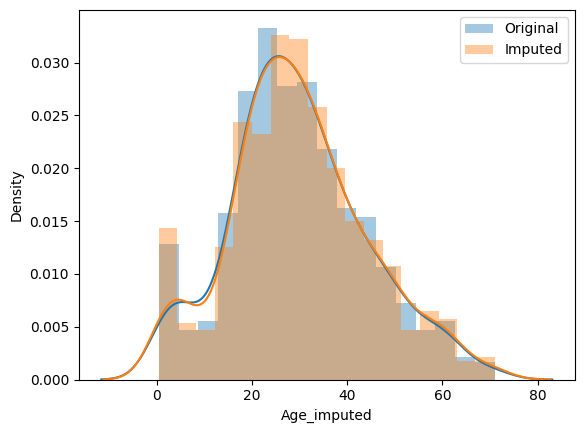

In [32]:
sns.distplot(X_train['Age'],label = 'Original')
sns.distplot(X_train['Age_imputed'],label = 'Imputed')


plt.legend()
plt.show()

In [33]:
print('Original Variable varience: ', X_train['Age'].var())
print('Varience After Random Imputed Variable : ', X_train['Age_imputed'].var())

Original Variable varience:  204.3495133904614
Varience After Random Imputed Variable :  209.65608813271425


In [34]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,48.384111
Age,71.512440,204.349513,204.349513
Age_imputed,48.384111,204.349513,209.656088


<Axes: >

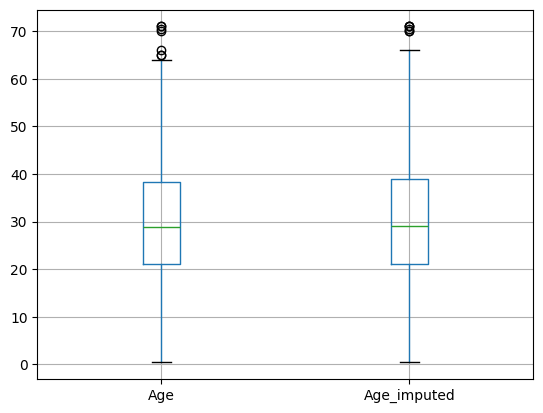

In [35]:
X_train[['Age','Age_imputed']].boxplot()

In [36]:
##  if we are using this imputation in production then it will give us Age values differnt for fare
## every time so we have to keep same price for same Age with Same Fare not Random fare

sampled_value = X_train['Age'].dropna().sample(1, random_state = int(observation['Fare']))

NameError: name 'observation' is not defined

In [39]:
data = pd.read_csv('house-train.csv',usecols = ['GarageQual','FireplaceQu','SalePrice'])

In [40]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [41]:
data.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [42]:
X = data
y = data['SalePrice']

In [43]:
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=2 )

In [44]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [45]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1276,TA,TA,162000,TA,TA
316,TA,TA,260000,TA,TA
1270,TA,TA,260000,TA,TA
42,NaN,TA,144000,TA,NaN
1007,NaN,TA,88000,TA,NaN


In [47]:
temp = pd.concat([X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
                  X_train['GarageQual_imputed'].value_counts() / len(X_train)
                  ],
                 axis = 1)

temp.columns = ['Original','Imputed']


In [49]:
temp

# no big changes so we can use it

,Original,Imputed
TA,0.951043,0.898116
Fa,0.037171,0.035103
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [51]:
temp = pd.concat([X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
                  X_train['FireplaceQu_imputed'].value_counts() / len(X_train)
                  ],
                 axis = 1)

temp.columns = ['Original','Imputed']


/tmp/ipykernel_2460/764138906.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], hist = False, label = category)
/tmp/ipykernel_2460/764138906.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['Firepla

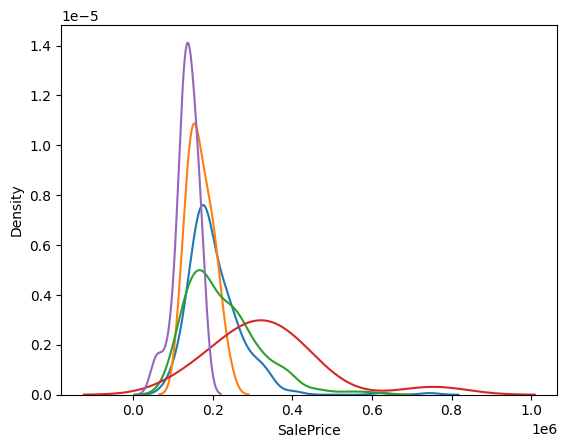

In [58]:
for category in X_train['FireplaceQu'].dropna().unique():
  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], hist = False, label = category)

#plt.legend()
plt.show()


/tmp/ipykernel_2460/1796071042.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], hist = False, label = category)
/tmp/ipykernel_2460/1796071042.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_trai

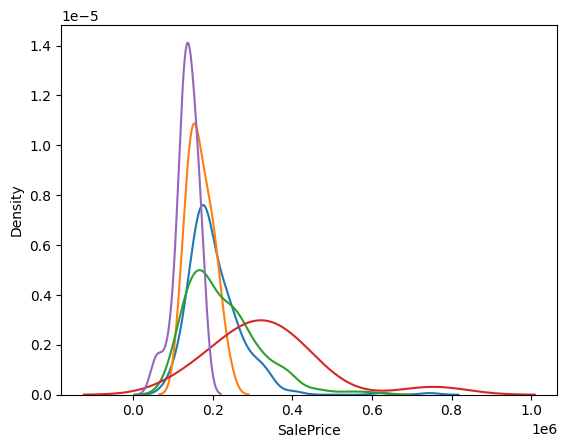

In [59]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], hist = False, label = category)

#plt.legend()
plt.show()
